## 1. Install Dependencies & Imports

In [12]:
# %pip install upstash_vector torch torchvision pillow transformers numpy tqdm

import os
import numpy as np
import torch
import random
from PIL import Image
from torchvision import transforms
from transformers import CLIPModel, CLIPProcessor
from tqdm import tqdm
from upstash_vector import Index

In [13]:
# UPSTASH CONFIGURATION
UPSTASH_VECTOR_URL = os.getenv("UPSTASH_VECTOR_REST_URL")
UPSTASH_VECTOR_TOKEN = os.getenv("UPSTASH_VECTOR_REST_TOKEN")
CSV_FILE="formatted_products_rows.csv"

index = Index(url=UPSTASH_VECTOR_URL, token=UPSTASH_VECTOR_TOKEN)

## 3. Load Images from Directory
This section iterates through your `IMAGE_DIR` and loads valid image files into memory.

In [ ]:
import csv
import ast

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def get_embedding(image):
    # Convert to RGB first - this is critical for RGBA images
    # ToTensor() will create a 4-channel tensor for RGBA, but Normalize expects 3 channels
    if image.mode != "RGB":
        image = image.convert("RGB")
    
    image_tensor = preprocess(image)
    image_batch = image_tensor.unsqueeze(0)
    with torch.no_grad():
        features = model.get_image_features(pixel_values=image_batch)
    embedding = features.squeeze().cpu().numpy()
    return embedding.astype(np.float32)

# vectors = []
# batch_size = 100
# total_count = 0

# with open(CSV_FILE, 'r') as f:
#     reader = csv.DictReader(f)
#     for row in tqdm(reader, desc="Processing"):
#         try:
#             image_path = row['image']
#             if not os.path.exists(image_path):
#                 continue
            
#             img = Image.open(image_path).convert("RGB")
#             embedding = get_embedding(img)
            
#             metadata_str = row['metadata']
#             metadata = ast.literal_eval(metadata_str)
            
#             vectors.append({
#                 "id": row['id'],
#                 "vector": embedding.tolist(),
#                 "metadata": metadata
#             })
            
#             if len(vectors) >= batch_size:
#                 index.upsert(vectors)
#                 total_count += len(vectors)
#                 vectors = []
#         except Exception as e:
#             print(f"Skipping {row.get('id', 'unknown')}: {e}")

# if vectors:
#     index.upsert(vectors)
#     total_count += len(vectors)

# print(f"Upserted {total_count} vectors to Upstash")

## 4. Load Model & Preprocessing
We use `openai/clip-vit-base-patch32`.

In [ ]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Alternative manual transform pipeline if not using processor
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def get_embedding(image):
    # Convert to RGB first - this is critical for RGBA images
    # ToTensor() will create a 4-channel tensor for RGBA, but Normalize expects 3 channels
    if image.mode != "RGB":
        image = image.convert("RGB")
    
    # Use the manual transform pipeline
    image_tensor = preprocess(image)
    image_batch = image_tensor.unsqueeze(0)

    with torch.no_grad():
        features = model.get_image_features(pixel_values=image_batch)
    
    embedding = features.squeeze().cpu().numpy()
    return embedding.astype(np.float32)

## 6. Query the Index
We will pick a random image from your local folder and ask Upstash to find the most similar images.

Querying using: data/output/images/JDB_JDB-14.jpeg


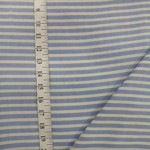


--- Search Results ---
1: Score=1.0000, ID=33804a69-9411-47d0-85d4-64df59a3a94a
   Metadata: {'source': 'JDB.pdf', 'design_no': 'JDB/14'}


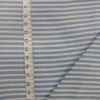

2: Score=0.9830, ID=34aae13d-56b2-4087-989e-a443048d43e4
   Metadata: {'source': 'POLYESTER.pdf', 'design_no': 'PF/12'}


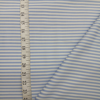

3: Score=0.9801, ID=84f2d170-9758-4078-9ce4-a1e75472bde5
   Metadata: {'source': 'POLYESTER.pdf', 'design_no': 'PF/14'}


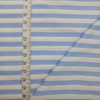

In [22]:
def query_image(image_obj, top_k=3):
    vector = get_embedding(image_obj)
    
    csv_data = {}
    with open(CSV_FILE, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            csv_data[row['id']] = row['image']
    
    try:
        res = index.query(vector=vector.tolist(), top_k=top_k, include_metadata=True)
        
        print("\n--- Search Results ---")
        for i, r in enumerate(res):
            score = r.score
            result_id = r.id
            metadata = r.metadata
            
            image_path = csv_data.get(result_id, 'Unknown')
            
            print(f"{i + 1}: Score={score:.4f}, ID={result_id}")
            print(f"   Metadata: {metadata}")
            
            if os.path.exists(image_path):
                display(Image.open(image_path).resize((100, 100)))
            else:
                print(f"   Image not found: {image_path}")
    except Exception as e:
        print(f"Query Error: {e}")

image_file = "data/output/images/JDB_JDB-14.jpeg"
image = Image.open(image_file)

print(f"Querying using: {image_file}")
display(image.resize((150, 150)))

query_image(image)
